# Ventes e-commerce : nettoyage et enrichissement

Le fichier de départ contient 525 000 lignes de ventes de meubles. Ici je fais tout le
traitement du début à la fin, et je montre mes vérifications au fur et à mesure.

## Ce que j'ai à faire

Il y a deux choses à faire sur ce fichier de ventes :

1. Trouver et corriger les lignes mal rangées dans les catégories.
2. Sortir les dimensions et les couleurs à partir des libellés produits.

Le but c'est de produire un fichier propre, avec un traitement que je peux relancer et qui
redonne le même résultat. J'utilise un petit modèle (TF-IDF + LogisticRegression) pour la
première tâche, mais c'est juste un outil de nettoyage. Je ne cherche pas à optimiser des
scores ni à comparer des modèles entre eux.

J'ai préféré rester simple, avec des choses faciles à expliquer et qui ne cassent pas,
plutôt que de faire compliqué.

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Je mets les chemins en dur : le notebook traite un fichier précis, dans un dossier
# précis. Pas besoin d'en faire des paramètres.
FICHIER_ENTREE = "ventes.xlsb"
FICHIER_SORTIE = "ventes_enrichies.xlsx"
FICHIER_CACHE = "ventes_cache.csv"

# Je ne remplace une Nature que si le modèle est sûr au moins à ce point-là. En dessous
# je garde la valeur d'origine : comme je n'ai rien pour vérifier, je préfère laisser
# une erreur plutôt que d'en rajouter une.
SEUIL_CONFIANCE = 0.75

# Je limite volontairement la liste des couleurs. Ça me donne une colonne propre et
# utilisable, au lieu d'une couleur différente à chaque formulation commerciale.
COULEURS = [
    "noir", "blanc", "gris", "beige", "taupe", "anthracite", "marron",
    "chêne", "naturel", "rouge", "bleu", "vert", "jaune", "rose", "orange",
    "violet", "doré", "argenté", "brun", "écru", "ivoire", "terracotta",
    "cuivre", "or", "argent",
]

# À l'export, le fichier a perdu ses accents : "chêne" y est toujours écrit
# "ch ne", sur environ 8 000 lignes.
CORRECTIONS = {"ch ne": "chêne", "blanche": "blanc"}

# Les formats de dimensions que je croise dans les libellés : "120x60",
# "120 x 60 x 75", "200*90cm".
MOTIF_DIMENSION = re.compile(r"(\d+)\s*[x×*]\s*(\d+)(?:\s*[x×*]\s*(\d+))?", re.IGNORECASE)

## Les fonctions du traitement

Je définis ici les quatre étapes, et je les appelle plus bas : lire le fichier, corriger la
Nature, sortir la dimension et la couleur, écrire le fichier final.

In [2]:
def charger_donnees(chemin=FICHIER_ENTREE):
    """Charge le fichier de ventes. Je passe par un cache CSV pour les relectures."""
    if Path(FICHIER_CACHE).exists():
        return pd.read_csv(FICHIER_CACHE)

    df = pd.read_excel(chemin, engine="pyxlsb")
    df.to_csv(FICHIER_CACHE, index=False)
    return df

In [3]:
def entrainer_modele(df):
    """Entraîne le modèle sur la Nature la plus fréquente de chaque libellé."""
    connu = df[["Libellé produit", "Nature"]].dropna()

    # value_counts trie du couple le plus fréquent au moins fréquent. Si je ne garde
    # que la première ligne de chaque libellé, je récupère sa Nature la plus fréquente.
    # Comme ça je n'apprends pas les incohérences déjà présentes dans le fichier.
    exemples = (
        connu.value_counts(["Libellé produit", "Nature"])
        .reset_index()
        .drop_duplicates("Libellé produit")
    )

    vectoriseur = TfidfVectorizer()
    x = vectoriseur.fit_transform(exemples["Libellé produit"].astype(str))
    y = exemples["Nature"].astype(str)

    # Le solveur saga tient bien la charge sur ce volume : environ 56 000 libellés
    # répartis en 596 catégories.
    modele = LogisticRegression(solver="saga")
    modele.fit(x, y)
    return modele, vectoriseur

In [4]:
def recategoriser(df, modele, vectoriseur, seuil=SEUIL_CONFIANCE):
    """Repère les lignes mal catégorisées et corrige leur Nature."""
    resultat = df.copy()
    resultat["Nature_originale"] = resultat["Nature"]

    libelles = resultat["Libellé produit"].fillna("").astype(str)

    # Je classe chaque libellé une seule fois, puis je reporte le résultat sur toutes
    # les lignes qui ont ce libellé.
    distincts = pd.Index(libelles.unique())
    probabilites = modele.predict_proba(vectoriseur.transform(distincts))
    proposition = pd.Series(modele.classes_[probabilites.argmax(axis=1)], index=distincts)
    confiance = pd.Series(probabilites.max(axis=1), index=distincts)

    a_corriger = libelles.map(confiance) >= seuil
    resultat.loc[a_corriger, "Nature"] = libelles.map(proposition)[a_corriger]
    return resultat

In [5]:
def trouver_dimension(libelle):
    """Renvoie la première dimension du libellé, toujours écrite 120x60x75."""
    trouvaille = MOTIF_DIMENSION.search(str(libelle))
    if trouvaille is None:
        return ""
    nombres = [n for n in trouvaille.groups() if n is not None]
    return "x".join(nombres)


def trouver_couleur(libelle):
    """Renvoie la première couleur de ma liste trouvée dans le libellé."""
    texte = str(libelle).lower()
    for faute, correction in CORRECTIONS.items():
        texte = texte.replace(faute, correction)

    for couleur in COULEURS:
        # Le \b évite qu'une couleur courte comme "or" soit trouvée dans "bordure".
        # Le e?s? à la fin gère le féminin et le pluriel.
        if re.search(r"\b" + couleur + r"e?s?\b", texte):
            return couleur
    return ""


def ajouter_dimension_et_couleur(df):
    """Ajoute les colonnes Dimension et Couleur au tableau."""
    resultat = df.copy()
    libelles = resultat["Libellé produit"].fillna("")
    resultat["Dimension"] = libelles.apply(trouver_dimension)
    resultat["Couleur"] = libelles.apply(trouver_couleur)
    return resultat

In [6]:
def sauvegarder(df, chemin=FICHIER_SORTIE):
    """Écrit le tableau enrichi en xlsx."""
    df.to_excel(chemin, index=False)

In [7]:
# La première lecture ouvre le .xlsb et prend environ 45 minutes. Ensuite, ça relit le
# cache CSV écrit au premier passage.
df = charger_donnees()
print(f"{len(df)} lignes, {len(df.columns)} colonnes")
df.head()

525034 lignes, 10 colonnes


,Cod_cmd,Libellé produit,Vendeur,Univers,Nature,Date de commande,Montant cmd,Quantité,Prix transport,Délai transport annoncé
0,182210782,Table basse carrée detroit design industriel,Autre vendeur,Canapé Salon Séjour,Table basse,44216,244,4,6.67,10.0
1,182082437,Ours en peluche géant 150 cm brun,Autre vendeur,Enfant Bébé,Peluche,44213,28,1,9.92,10.0
2,182095765,Ours en peluche géant 100 cm blanc,Autre vendeur,Enfant Bébé,Peluche,44214,15,1,9.92,10.0
3,182615392,Lot de 4 chaises mia noires pour salle à manger,Autre vendeur,Canapé Salon Séjour,Chaise,44219,385,2,20.75,10.0
4,184222081,Meuble tv falko bois blanc et gris,Autre vendeur,Canapé Salon Séjour,Meuble tv,44238,61,1,19.08,10.0


## 1. Je regarde le fichier de départ

Avant de corriger quoi que ce soit, je veux voir comment le fichier est fait : les colonnes,
le nombre de catégories et ce qui manque.

In [8]:
print("Colonnes :", list(df.columns))
print("Univers :", df["Univers"].nunique())
print("Natures :", df["Nature"].nunique())
print()
print("Valeurs manquantes :")
print(df.isna().sum())

Colonnes : ['Cod_cmd', 'Libellé produit', 'Vendeur', 'Univers', 'Nature', 'Date de commande', 'Montant cmd', 'Quantité', 'Prix transport', 'Délai transport annoncé']
Univers : 10
Natures : 596

Valeurs manquantes :
Cod_cmd                         0
Libellé produit                 0
Vendeur                         0
Univers                     17687
Nature                      11745
Date de commande                0
Montant cmd                     0
Quantité                        0
Prix transport                  0
Délai transport annoncé    239423
dtype: int64


In [9]:
natures_avant = df["Nature"].value_counts()
print("Les 10 natures les plus fréquentes :")
natures_avant.head(10)

Les 10 natures les plus fréquentes :


Nature
Matelas                35593
Lit adulte             21133
Meuble à chaussures    19105
Chaise                 15591
Bureau                 15409
Lave linge             14639
Bibliotheque           14129
Armoire                13316
Table basse            12530
Meuble tv              12488
Name: count, dtype: int64

In [10]:
# Petite vérification : normalement un même libellé produit devrait avoir une seule
# Nature. Ce que je trouve ici explique pourquoi je ne garde que la Nature la plus
# fréquente pour l'entraînement.
connu = df.dropna(subset=["Nature"])
nb_natures = connu.groupby("Libellé produit")["Nature"].nunique()
print(f"Libellés avec plusieurs Natures : {(nb_natures > 1).sum()} sur {len(nb_natures)}")
print(f"Lignes concernées : {connu['Libellé produit'].map(nb_natures).gt(1).sum()}")

exemple = "Matelas mousse 140x190 cm"
connu.loc[connu["Libellé produit"] == exemple, "Nature"].value_counts()

Libellés avec plusieurs Natures : 2189 sur 56012
Lignes concernées : 89200


Nature
Matelas                1178
Meuble à chaussures     803
Name: count, dtype: int64

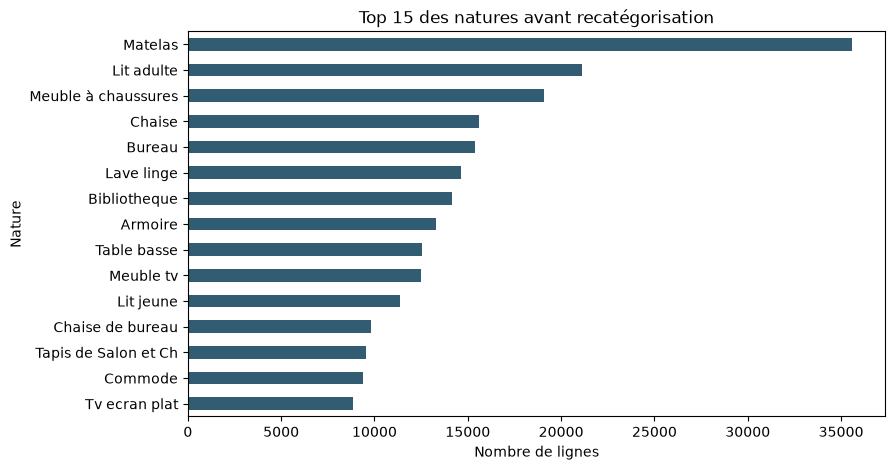

In [11]:
natures_avant.head(15).sort_values().plot.barh(figsize=(9, 5), color="#315c72")
plt.title("Top 15 des natures avant recatégorisation")
plt.xlabel("Nombre de lignes")
plt.show()

## 2. Tâche 1 : corriger les catégories

J'entraîne le modèle sur les lignes déjà catégorisées, puis je l'applique à tout le fichier
pour repérer les libellés dont la Nature ne colle pas avec le reste du catalogue. C'est un
outil de nettoyage, ce que je livre au final c'est le fichier corrigé.

Trois choix importants ici.

- J'entraîne sur les libellés distincts, 56 000 au lieu de 525 000 lignes. Un produit très
  vendu ne doit pas peser plus qu'un autre, et l'entraînement prend 40 secondes.
- Je ne garde que la Nature la plus fréquente de chaque libellé. Sinon le modèle apprend les
  erreurs vues juste avant et les recopie sur le reste du fichier.
- Je ne remplace une Nature que si le modèle est sûr à plus de 75 %. En dessous, je garde la
  valeur d'origine.

In [12]:
# J'entraîne le modèle sur les libellés déjà catégorisés, puis je l'applique à tout le
# fichier pour repérer les lignes qui semblent mal saisies.
modele, vectoriseur = entrainer_modele(df)
df_recat = recategoriser(df, modele, vectoriseur, seuil=SEUIL_CONFIANCE)

changees = df_recat["Nature_originale"].fillna("") != df_recat["Nature"].fillna("")
print(f"Lignes recatégorisées : {changees.sum()} / {len(df_recat)} ({changees.mean():.1%})")

Lignes recatégorisées : 17959 / 525034 (3.4%)


### Les corrections faites

Je relis à la main les corrections qui reviennent le plus souvent. C'est la seule
vérification que je peux faire, je n'ai pas d'échantillon de référence.

In [13]:
changements = df_recat.loc[changees, ["Nature_originale", "Nature"]]
print("Les 15 corrections les plus fréquentes (avant -> après) :")
changements.value_counts().head(15)

Les 15 corrections les plus fréquentes (avant -> après) :


Nature_originale      Nature             
Meuble à chaussures   Matelas                9573
Friteuse              Canapé d'angle         1258
                      Canape droit           1102
Buffet de cuisine     Buffet                  608
Meuble haut cuisine   Hotte                   391
Montage Lit           Lit adulte              353
Meuble à chaussures   Lit jeune               299
Lampadaire liseuse    Lampadaire              284
Etagère               Bibliotheque            270
Meuble à chaussures   Matelas + sommier       248
Accessoire aspi       Aspirateur traineau     237
Friteuse              Table basse             233
Mini mobilier enfant  Fauteuil                184
Meuble à chaussures   Surmatelas              173
Montage Bureau        Bureau                  152
Name: count, dtype: int64

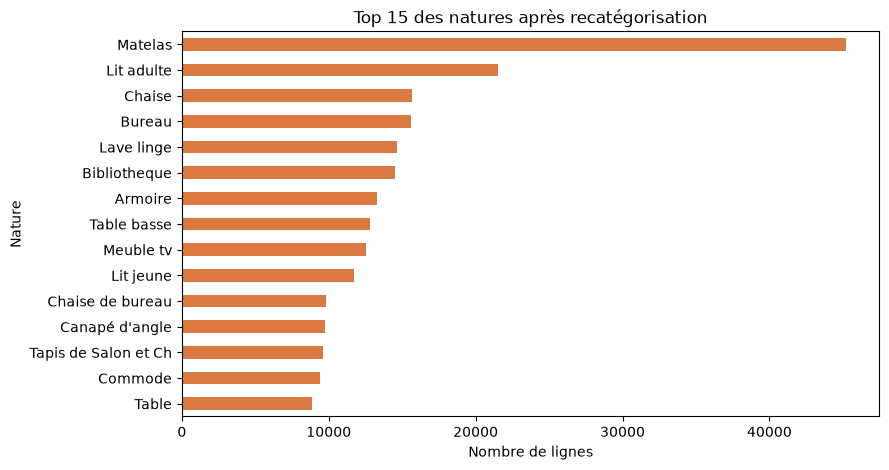

In [14]:
df_recat["Nature"].value_counts().head(15).sort_values().plot.barh(figsize=(9, 5), color="#d97941")
plt.title("Top 15 des natures après recatégorisation")
plt.xlabel("Nombre de lignes")
plt.show()

## 3. Tâche 2 : sortir les dimensions et les couleurs

Pas de modèle ici. Le format des dimensions est toujours le même et ma liste de couleurs est
fermée, donc deux règles simples suffisent et je peux les vérifier facilement.

- Dimension : un motif du type `120x60` ou `120 x 60 x 75`, que je réécris toujours pareil.
- Couleur : la première couleur de `COULEURS` que je trouve dans le libellé.

In [15]:
enrichi = ajouter_dimension_et_couleur(df_recat)

print(f"Dimensions trouvées : {(enrichi['Dimension'] != '').mean():.1%}")
print(f"Couleurs trouvées   : {(enrichi['Couleur'] != '').mean():.1%}")

Dimensions trouvées : 30.1%
Couleurs trouvées   : 22.4%


In [16]:
enrichi.loc[enrichi["Couleur"] != "", "Couleur"].value_counts().head(10)

Couleur
blanc      39151
noir       30673
gris       20064
chêne       4365
marron      4361
bleu        4295
beige       2406
naturel     1578
rouge       1547
brun        1470
Name: count, dtype: int64

### Je vérifie sur quelques lignes

In [17]:
enrichi.loc[
    (enrichi["Dimension"] != "") & (enrichi["Couleur"] != ""),
    ["Libellé produit", "Nature_originale", "Nature", "Dimension", "Couleur"],
].head(10)

,Libellé produit,Nature_originale,Nature,Dimension,Couleur
26,Panneau décoratif universel 160x60 cm flower gris,Panneau,Panneau,160x60,gris
113,Couette bicolore gris foncé et gris 200x200 cm...,Housse de couette,Housse de couette,200x200,gris
205,Meuble de salle de bain sur pied meuble de ran...,Element bas SDB,Element bas SDB,60x30x82,blanc
206,Meuble de salle de bain sur pied meuble de ran...,Element bas SDB,Element bas SDB,60x30x82,blanc
235,Banc coffre de rangement pouf de rangement pli...,Pouf / repose pied,Pouf / repose pied,76x38x38,blanc
238,Xxl armoire de rangement penderie dressing en ...,Structure armoire,Structure armoire,175x150x45,noir
239,Xxl armoire de rangement penderie dressing en ...,Structure armoire,Structure armoire,175x150x45,noir
246,Songmics xxl armoire etagère de rangement en p...,Dressing complet,Dressing complet,4x5,noir
247,Songmics xxl armoire etagère de rangement en p...,Dressing complet,Dressing complet,4x5,noir
249,Xxl armoire de rangement penderie dressing en ...,Structure armoire,Structure armoire,175x150x45,gris


## 4. J'écris le fichier final

In [18]:
# L'écriture prend quelques minutes pour 525 000 lignes en xlsx.
sauvegarder(enrichi)
print("Fichier écrit :", FICHIER_SORTIE)

Fichier écrit : ventes_enrichies.xlsx


## Conclusion et limites

Au final, la correction des catégories touche environ 18 000 lignes (3,5 %), et ce sont
surtout de vraies erreurs de saisie : des matelas rangés en « Meuble à chaussures », des
canapés rangés en « Friteuse ».

- Le modèle apprend sur les étiquettes déjà présentes. Garder la Nature la plus fréquente
  par libellé limite la casse, mais si une catégorie est fausse à plus de 50 % elle reste
  fausse.
- Je n'ai rien pour vérifier mes résultats. Le taux de correction, je le constate, je ne le
  mesure pas. La suite logique serait de relire un échantillon à la main.
- Les 11 745 lignes sans Nature sont des services ("1 an d'assistance téléphonique PC",
  "Adhérer au programme fidélité"). Il n'y a ni Univers ni produit équivalent, donc je les
  laisse vides, c'est le comportement voulu.
- Le fichier a perdu ses accents à l'export : "chêne" y est toujours écrit "ch ne" (8 000
  lignes), "hêtre" devient "h tre". Je corrige les cas que j'ai croisés dans `CORRECTIONS`.
- Ma liste de couleurs est volontairement fermée. Je rate des nuances commerciales ("bois
  flotté", "gris perle"), mais j'ai une colonne propre et utilisable derrière.
- Pour les dimensions, je prends la première trouvée et je ne regarde pas l'unité (cm ou mm).

### Comment je situe cet exercice

Pour moi c'est du data engineering : je nettoie et j'enrichis un fichier pour qu'il serve
derrière. Le modèle est un outil de nettoyage, pas le livrable.

Si c'était un vrai projet de data science, il aurait fallu :
- Un jeu de test étiqueté à la main pour mesurer la vraie précision.
- Comparer plusieurs modèles sérieusement (embeddings SBERT, un BERT fine-tuné).
- Une validation croisée stratifiée par Nature.
- Régler finement les hyperparamètres.
- Des métriques par classe (précision, rappel, F1).

Je ne l'ai pas fait parce que ce n'était pas le but : je voulais un fichier utilisable, avec
un bon compromis entre simplicité et efficacité vu la taille du fichier et le temps que
j'avais.